# Instalação de depedencias e configuração

In [3]:
!pip install numpy matplotlib scikit-learn pandas
!pip install --upgrade pip

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.datasets as datasets

In [5]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('dark_background')

# Dataset

In [6]:
#data set
x, y = datasets.make_moons(n_samples=500, noise=0.05)

In [7]:
print(f'{x.shape = }, {y.shape = }')

x.shape = (500, 2), y.shape = (500,)


In [8]:
pd.DataFrame({'x_1': x[:, 0], 'x_2': x[:, 1], 'y': y})

,x_1,x_2,y
0,0.631713,0.732393,0
1,0.012287,1.050180,0
2,1.678140,-0.111426,1
3,0.384342,-0.271429,1
4,-0.339244,0.845061,0
...,...,...,...
495,0.933079,0.177314,0
496,-0.596967,0.773031,0
497,0.228017,0.898687,0
498,0.999636,-0.565567,1


In [9]:
unique = np.unique(y, return_counts=True)
for label, qt_label in zip(unique[0], unique[1]):
    print(f'label: {label}\t Counts: {qt_label}')

label: 0	 Counts: 250
label: 1	 Counts: 250


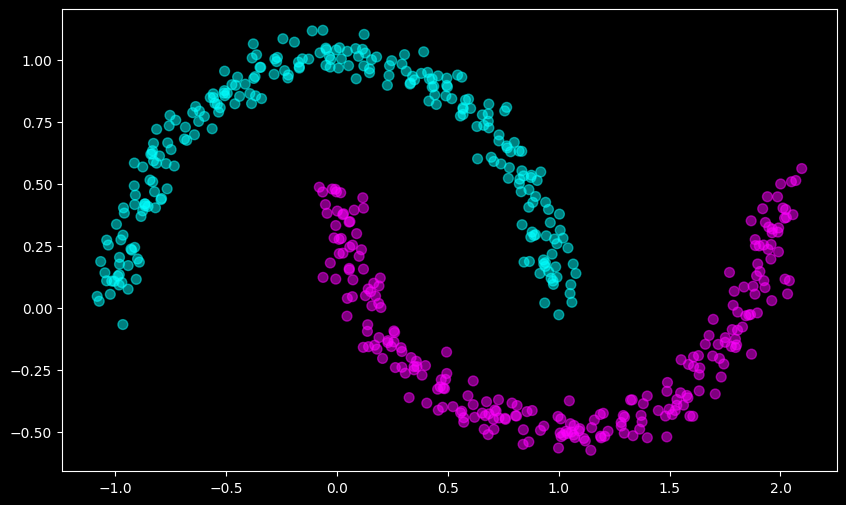

In [10]:
plt.scatter(x[:, 0], x[:, 1], c=y, s=50, alpha=0.5, cmap='cool')

# Modelo

In [11]:
class NnModel:
    def __init__(self, x: np.ndarray, y: np.ndarray, hidden_neurons: int = 10, output_neurons: int = 2):
        np.random.seed(8)
        self.x = x
        self.y = y
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.input_neurons = self.x.shape[1]

        # inicializa os pesos e bias

        # Xavier inicialization -> variação uniforme dos pesos
        # entrada -> neuronios
        self.W1 = np.random.randn(self.input_neurons, self.hidden_neurons) / np.sqrt(self.input_neurons)
        self.B1 = np.zeros((1, self.hidden_neurons))

        # neuronios -> saida
        self.W2 = np.random.randn(self.hidden_neurons, self.output_neurons) / np.sqrt(self.hidden_neurons)
        self.B2 = np.zeros((1, self.output_neurons))

        # dicionario do modelo
        self.model_dict = {'W1': self.W1, 'B1': self.B1, 'W2': self.W2, 'B2': self.B2}

        # Somatorio da camadas dos neuronios (hidden)
        self.z1 = 0

        # função de ativação da camada dos neuronios (hidden)
        self.f1 = 0

    def forward(self, x: np.ndarray) -> np.ndarray:
        # Equação da reta
        self.z1 = x.dot(self.W1) + self.B1

        # Função de ativação (1)
        self.f1 = np.tanh(self.z1)

        # Equação da reta (2)
        z2 = self.f1.dot(self.W2) + self.B2

        # Softmax
        exp_values = np.exp(z2)
        soft_max = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        return soft_max

    def loss(self, soft_max: np.ndarray) -> np.ndarray:
        # Cross Entropy
        predicted = 0
        predictions = np.zeros(self.y.shape[0])

        for i, correct_index in enumerate(self.y):
            predicted = soft_max[i][correct_index]
            predictions[i] = predicted

        log_prob = -np.log(predicted)
        media = log_prob / self.y.shape[0]

        return media

    def backpropagation(self, soft_max: np.ndarray, learning_rate: float) -> None:
        delta2 = np.copy(soft_max)
        delta2[range(self.x.shape[0]), self.y] -= 1
        dW2 = (self.f1.T).dot(delta2)
        dB2 = np.sum(delta2, axis=0, keepdims=True)
        delta1 = delta2.dot(self.W2.T) * (1 - np.power(np.tanh(self.z1), 2))
        dW1 = (self.x.T).dot(delta1)
        dB1 = np.sum(delta1, axis=0, keepdims=True)

        # Atualização dos pesos e bias
        self.W1 += - learning_rate * dW1
        self.W2 += - learning_rate * dW2
        self.B1 += - learning_rate * dB1
        self.B2 += - learning_rate * dB2

    def fit(self, epochs: int, lr: float):
        prediction = np.zeros(self.y.shape[0])
        for epoch in range(epochs):
            outputs = self.forward(self.x)
            loss = self.loss(outputs)
            self.backpropagation(outputs, lr)

            # Acuracia
            prediction = np.argmax(outputs, axis=1)
            correct = (prediction == self.y).sum()
            accuracy = correct / self.y.shape[0]

            if int((epoch + 1) % (epochs / 10)) == 0:
                print(f'Epoch: [{epoch + 1} / {epochs}]   Accuracy: {accuracy:.3f}   Loss: {loss.item():.4f}')
        return prediction



In [12]:
hidden_neurons = 50
output_neurons = 3
learning_rate = 0.008
epochs = 50

rede_neural = NnModel(x, y, hidden_neurons, output_neurons)
result = rede_neural.fit(epochs, learning_rate)

Epoch: [5 / 50]   Accuracy: 0.624   Loss: 0.0002
Epoch: [10 / 50]   Accuracy: 0.544   Loss: 0.0038
Epoch: [15 / 50]   Accuracy: 0.742   Loss: 0.0000
Epoch: [20 / 50]   Accuracy: 0.858   Loss: 0.0008
Epoch: [25 / 50]   Accuracy: 0.818   Loss: 0.0000
Epoch: [30 / 50]   Accuracy: 0.896   Loss: 0.0000
Epoch: [35 / 50]   Accuracy: 0.876   Loss: 0.0000
Epoch: [40 / 50]   Accuracy: 0.942   Loss: 0.0000
Epoch: [45 / 50]   Accuracy: 0.980   Loss: 0.0000
Epoch: [50 / 50]   Accuracy: 1.000   Loss: 0.0000


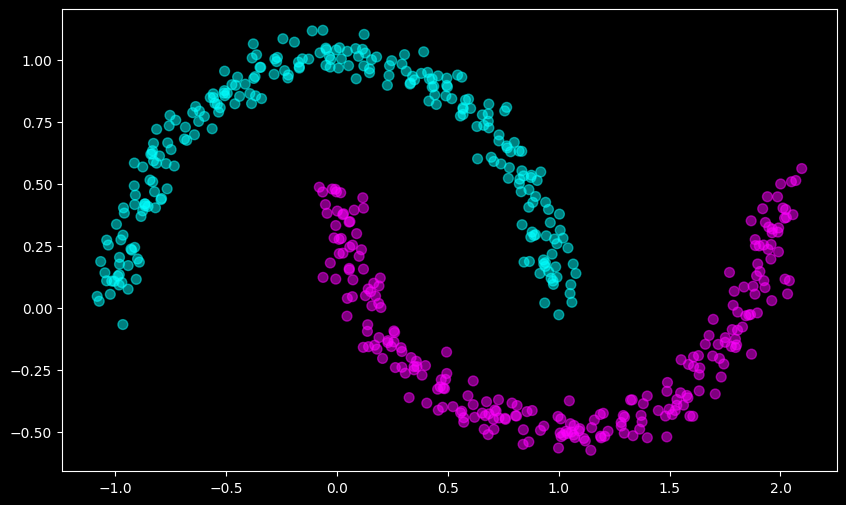

In [13]:
plt.scatter(x[:, 0], x[:, 1], c=result, s=50, alpha=0.5, cmap='cool')
